In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2, ResNet50V2, EfficientNetB2, EfficientNetB7, InceptionV3, EfficientNetV2B3
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Concatenate, Input
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os

2026-02-08 14:02:44.383045: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-08 14:02:44.978060: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-08 14:02:46.686196: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# Check if GPU detected?
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    for i, gpu in enumerate(gpus):
        # Get Specifications Details
        details = tf.config.experimental.get_device_details(gpu)
        gpu_name = details.get('device_name', 'Unknown GPU')
        compute_cap = details.get('compute_capability', 'Unknown')
        
        print(f"\n--- GPU #{i} ---")
        print(f"Name       : {gpu_name}")
        print(f"ID Path    : {gpu.name}")
        print(f"Compute Cap: {compute_cap}")
        
    # Built and Additional information
    print("\n--- Additional Information ---")
    print(f"TensorFlow Version          : {tf.__version__}")
    print(f"Built with CUDA             : {tf.test.is_built_with_cuda()}")
    print(f"Compute Capabilities Build  : {tf.sysconfig.get_build_info()['cuda_compute_capabilities']}")
else:
    print("❌ GPU Not Detected!")


--- GPU #0 ---
Name       : NVIDIA GeForce RTX 5060
ID Path    : /physical_device:GPU:0
Compute Cap: (12, 0)

--- Additional Information ---
TensorFlow Version          : 2.20.0-dev0+selfbuilt
Built with CUDA             : True
Compute Capabilities Build  : ['compute_120', 'compute_89', 'compute_86', 'compute_75', 'compute_61']


In [3]:
ROOT_DIR = "/media/DATA/.kaggle/autism-spectrum"
EPOCHS = 20
BATCH_SIZE = 32
IMG_SIZE = 224
IMG_SHAPE = (IMG_SIZE, IMG_SIZE)

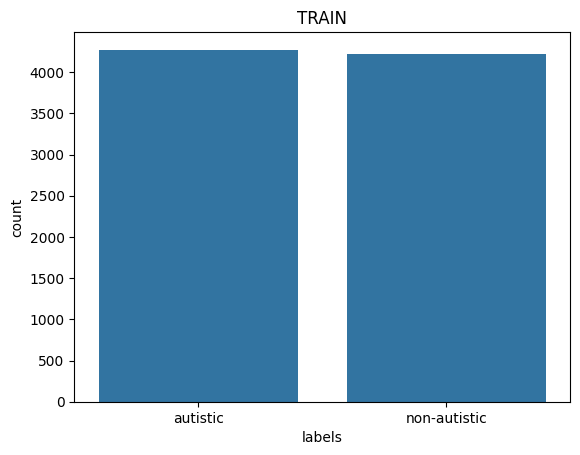

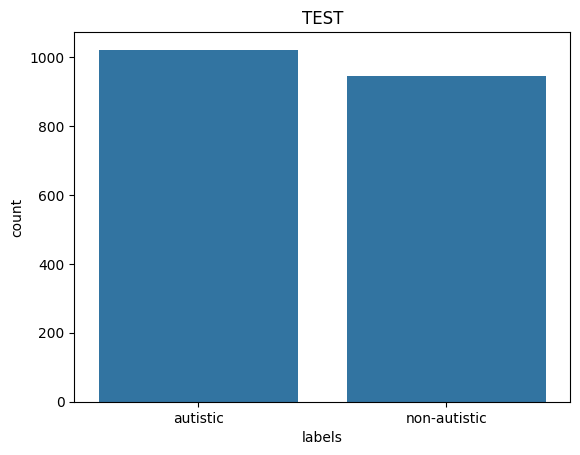

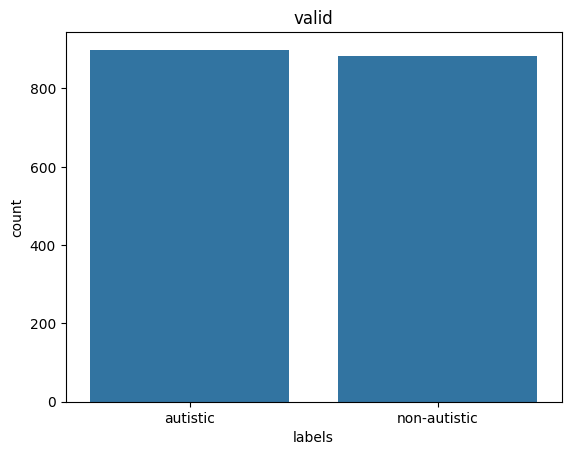

In [4]:
train_df = pd.read_csv(f"{ROOT_DIR}/Cleaned Dataset/cleaned_train.csv")
test_df = pd.read_csv(f"{ROOT_DIR}/Cleaned Dataset/cleaned_test.csv")
valid_df = pd.read_csv(f"{ROOT_DIR}/Cleaned Dataset/cleaned_valid.csv")

sns.countplot(x='labels',data=train_df)
plt.title('TRAIN')
plt.show()
sns.countplot(x='labels',data=test_df)
plt.title('TEST')
plt.show()
sns.countplot(x='labels',data=valid_df)
plt.title('valid')
plt.show()

In [5]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
)
train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",             # column with image names
    y_col="labels",                # column with labels
    target_size=IMG_SHAPE,       # resize images
    batch_size=BATCH_SIZE,
    class_mode="binary",     # or "binary", "sparse", or None
)

Found 8496 validated image filenames belonging to 2 classes.


In [6]:
test_datagen = ImageDataGenerator(rescale=1./255,)
test_gen = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",             # column with image names
    y_col="labels",                # column with labels
    target_size=IMG_SHAPE,       # resize images
    batch_size=BATCH_SIZE,
    class_mode="binary",     # or "binary", "sparse", or None
    shuffle=False
)

Found 1966 validated image filenames belonging to 2 classes.


In [7]:
valid_datagen = ImageDataGenerator(rescale=1./255,)
valid_gen = valid_datagen.flow_from_dataframe(
    dataframe=valid_df,
    x_col="image_path",             # column with image names
    y_col="labels",                # column with labels
    target_size=IMG_SHAPE,       # resize images
    batch_size=BATCH_SIZE,
    class_mode="binary",     # or "binary", "sparse", or None
)

Found 1782 validated image filenames belonging to 2 classes.


In [8]:
# --- BUILD DUAL-BACKBONE MODEL (FIXED) ---
num_classes = len(train_gen.class_indices)
# 1 single input
inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# 2 backbones: instantiate WITHOUT input_shape so they don't create their own Input layers
mobilenet_backbone = MobileNetV2(include_top=False, weights="imagenet")
resnet_backbone = ResNet50V2(include_top=False, weights="imagenet")

# Freeze both initially
mobilenet_backbone.trainable = False
resnet_backbone.trainable = False

# Call both backbones on the SAME input tensor
m_feat = mobilenet_backbone(inputs)      # feature map from MobileNet
r_feat = resnet_backbone(inputs)         # feature map from ResNet

# Pool and combine
m_pool = GlobalAveragePooling2D()(m_feat)
r_pool = GlobalAveragePooling2D()(r_feat)

combined = Concatenate()([m_pool, r_pool])
combined = Dense(512, activation="relu")(combined)
combined = Dropout(0.5)(combined)

outputs = Dense(1, activation="sigmoid")(combined)

model = Model(inputs=inputs, outputs=outputs)

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

model.summary()

/tmp/ipykernel_19127/848079698.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet_backbone = MobileNetV2(include_top=False, weights="imagenet")
I0000 00:00:1770534170.366851   19127 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1392 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060, pci bus id: 0000:01:00.0, compute capability: 12.0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ input_layer[0][0] │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50v2          │ (None, 7, 7,      │ 23,564,800 │ input_layer[0][0] │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50v2[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 3328)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │  1,704,448 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │        513 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 27,527,745 (105.01 MB)

 Trainable params: 1,704,961 (6.50 MB)

 Non-trainable params: 25,822,784 (98.51 MB)

In [9]:
# === CALLBACKS ===
checkpoint = ModelCheckpoint("asr_backbone.keras", monitor="accuracy", save_best_only=True)
earlystop = EarlyStopping(monitor="accuracy", patience=6, restore_best_weights=True)

In [10]:
# === TRAIN ===
history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=valid_gen,
    callbacks=[checkpoint, earlystop]
)

Epoch 1/20


2026-02-08 14:02:56.471368: I external/local_xla/xla/service/service.cc:153] XLA service 0x7f91a8001f70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-08 14:02:56.471386: I external/local_xla/xla/service/service.cc:161]   StreamExecutor device (0): NVIDIA GeForce RTX 5060, Compute Capability 12.0
2026-02-08 14:02:56.607513: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1770534177.698877   19845 cuda_dnn.cc:529] Loaded cuDNN version 91701
2026-02-08 14:02:58.624825: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_9128', 436 bytes spill stores, 436 bytes spill loads

2026-02-08 14:03:02.180765: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optima

 78/266 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.6618 - loss: 0.8243

2026-02-08 14:03:17.075816: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.16GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


266/266 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.7208 - loss: 0.6395

2026-02-08 14:03:35.447921: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2655', 436 bytes spill stores, 436 bytes spill loads

2026-02-08 14:03:40.115963: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.18GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


266/266 ━━━━━━━━━━━━━━━━━━━━ 52s 138ms/step - accuracy: 0.7644 - loss: 0.5120 - val_accuracy: 0.8260 - val_loss: 0.4090
Epoch 2/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 13s 49ms/step - accuracy: 0.8306 - loss: 0.3727 - val_accuracy: 0.8378 - val_loss: 0.3488
Epoch 3/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 13s 49ms/step - accuracy: 0.8658 - loss: 0.3096 - val_accuracy: 0.8547 - val_loss: 0.3272
Epoch 4/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - accuracy: 0.8889 - loss: 0.2641 - val_accuracy: 0.8934 - val_loss: 0.2486
Epoch 5/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - accuracy: 0.9162 - loss: 0.2062 - val_accuracy: 0.9052 - val_loss: 0.2223
Epoch 6/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - accuracy: 0.9351 - loss: 0.1687 - val_accuracy: 0.9388 - val_loss: 0.1699
Epoch 7/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 13s 49ms/step - accuracy: 0.9508 - loss: 0.1374 - val_accuracy: 0.9484 - val_loss: 0.1526
Epoch 8/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 13s 49ms/step - accuracy: 0.9544 - loss: 0.1136 - val_accura

In [11]:
# === EVALUATION ===
loss, acc = model.evaluate(test_gen)
print(f"\n🔥 Model Accuracy: {acc * 100:.2f}%")
print(f"📉 Model Loss: {loss:.4f}")

61/62 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.9716 - loss: 0.1115

2026-02-08 14:08:00.771676: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.15GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


62/62 ━━━━━━━━━━━━━━━━━━━━ 19s 311ms/step - accuracy: 0.9720 - loss: 0.1120

🔥 Model Accuracy: 97.20%
📉 Model Loss: 0.1120


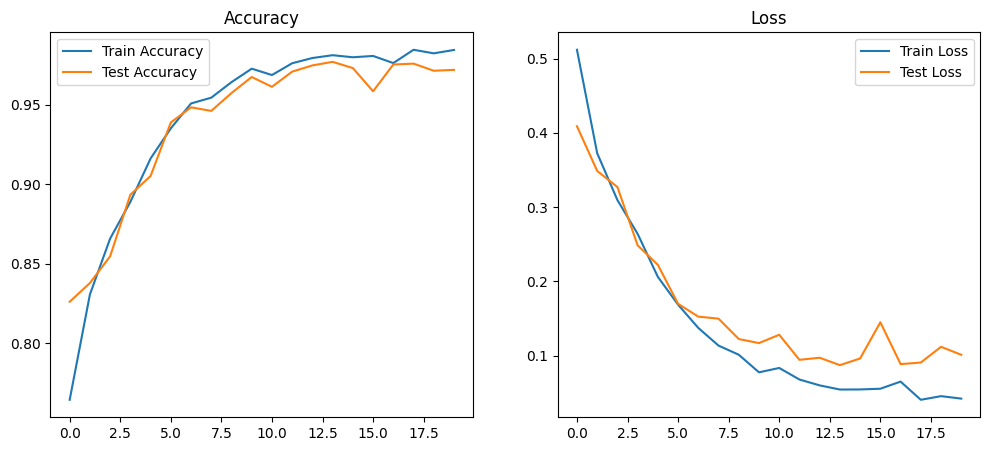

In [12]:
# === VISUALIZE TRAINING ===
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Test Accuracy")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Test Loss")
plt.title("Loss")
plt.legend()

plt.show()

62/62 ━━━━━━━━━━━━━━━━━━━━ 12s 113ms/step
              precision    recall  f1-score   support

    autistic       0.97      0.98      0.97      1021
non-autistic       0.98      0.96      0.97       945

    accuracy                           0.97      1966
   macro avg       0.97      0.97      0.97      1966
weighted avg       0.97      0.97      0.97      1966



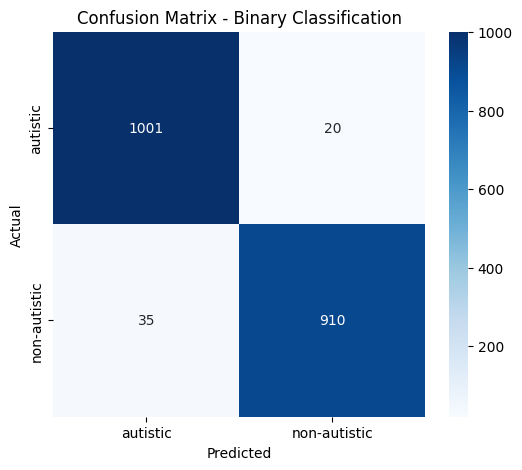

In [13]:
# 1. Ambil prediksi dalam bentuk probabilitas (0.0 sampai 1.0)
y_pred = model.predict(test_gen)

# 2. Ubah probabilitas jadi 0 atau 1 pake threshold 0.5
# Jangan pake argmax buat binary (1 output node)!
y_pred_class = (y_pred > 0.5).astype("int32").flatten()

# 3. Ambil label asli (ground truth)
y_true = test_gen.classes  
class_labels = list(test_gen.class_indices.keys())

# Sekarang print report-nya, pasti lebih masuk akal
print(classification_report(y_true, y_pred_class, target_names=class_labels))

# =============================
#  CONFUSION MATRIX
# =============================
cm = confusion_matrix(y_true, y_pred_class)

# Visualisasi tetep sama, tapi isinya udah bener
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix - Binary Classification")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()